In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("algozee/teenager-menthal-healy")

print("Path to dataset files:",
      path)

Path to dataset files: /Users/zadyra/.cache/kagglehub/datasets/algozee/teenager-menthal-healy/versions/1


In [2]:
import os
import pandas as pd
print(os.listdir(path))

['Teen_Mental_Health_Dataset.csv']


In [3]:
filename = "Teen_Mental_Health_Dataset.csv" 
file_path = os.path.join(path, filename)

df = pd.read_csv(file_path)
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [4]:
df["social_interaction_level"].value_counts()

social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64

In [5]:
df["anxiety_level"].value_counts()

anxiety_level
6     132
4     131
10    131
8     130
9     124
3     123
2     110
7     109
1     105
5     105
Name: count, dtype: int64

In [6]:
df["depression_label"].value_counts()

depression_label
0    1169
1      31
Name: count, dtype: int64

In [7]:
"""
Questions
1. Who is more prone to social media addiction, female or male; at what age
2. Does the amount of daily social media hours correlate with the depression 
3. is there a correlation between addiction level and academic performance 
4. does physical activity has a positive effect on academic performance
5. do the ones with good academic performance have less screen time
6. does addiciton affect social interaction level
7. High addiction level = high stress level? 
8. Is there any platform that affects teenages the most (higher anxiety, depression, lower academic performance and etc)
9. Which age is the most vulnerable for social media addiction
10. 
"""

'\nQuestions\n1. Who is more prone to social media addiction, female or male; at what age\n2. Does the amount of daily social media hours correlate with the depression \n3. is there a correlation between addiction level and academic performance \n4. does physical activity has a positive effect on academic performance\n5. do the ones with good academic performance have less screen time\n6. does addiciton affect social interaction level\n7. High addiction level = high stress level? \n8. Is there any platform that affects teenages the most (higher anxiety, depression, lower academic performance and etc)\n9. Which age is the most vulnerable for social media addiction\n10. \n'

---
# Соцсети vs Подростки: данные рассказывают историю

**Центральный вопрос:** Как социальные сети разрушают здоровье, учёбу и социализацию подростков?

**Арка:** От «вот сколько они сидят онлайн» → «вот что это с ними делает» → «и кто пострадал больше всего»

---

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Reload data cleanly
import kagglehub, os
path = kagglehub.dataset_download("algozee/teenager-menthal-healy")
df = pd.read_csv(os.path.join(path, "Teen_Mental_Health_Dataset.csv"))

# Colour palette
C_BAD   = '#e74c3c'   # red   — concerning / high risk
C_GOOD  = '#2ecc71'   # green — positive / safe
C_GREY  = '#95a5a6'   # grey  — neutral / comparison
C_BLUE  = '#3498db'   # blue  — secondary highlight
C_ORANGE= '#e67e22'   # orange — middle ground

sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams['figure.dpi'] = 120

# Pre-computed helper columns used across questions
df['addiction_group'] = pd.cut(
    df['addiction_level'], bins=[0, 3, 6, 10],
    labels=['Low (1-3)', 'Medium (4-6)', 'High (7-10)']
)
df['academic_quartile'] = pd.qcut(
    df['academic_performance'], q=4,

    labels=['Q1 (worst)', 'Q2', 'Q3', 'Q4 (best)']
)

print('Dataset shape:', df.shape)
df.describe().round(2)

Dataset shape: (1200, 15)


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,15.93,4.54,6.45,1.74,2.99,1.01,5.45,5.64,5.56,0.03
std,2.02,2.03,1.44,0.72,0.58,0.58,2.90,2.86,2.83,0.16
min,13.00,1.00,4.00,0.50,2.00,0.00,1.00,1.00,1.00,0.00
25%,14.00,2.80,5.20,1.10,2.50,0.50,3.00,3.00,3.00,0.00
50%,16.00,4.50,6.50,1.80,2.99,1.00,5.00,6.00,6.00,0.00
75%,18.00,6.30,7.60,2.40,3.48,1.50,8.00,8.00,8.00,0.00
max,19.00,8.00,9.00,3.00,4.00,2.00,10.00,10.00,10.00,1.00


---
## Q1. Кто зависимее: девочки или мальчики — и в каком возрасте пик?

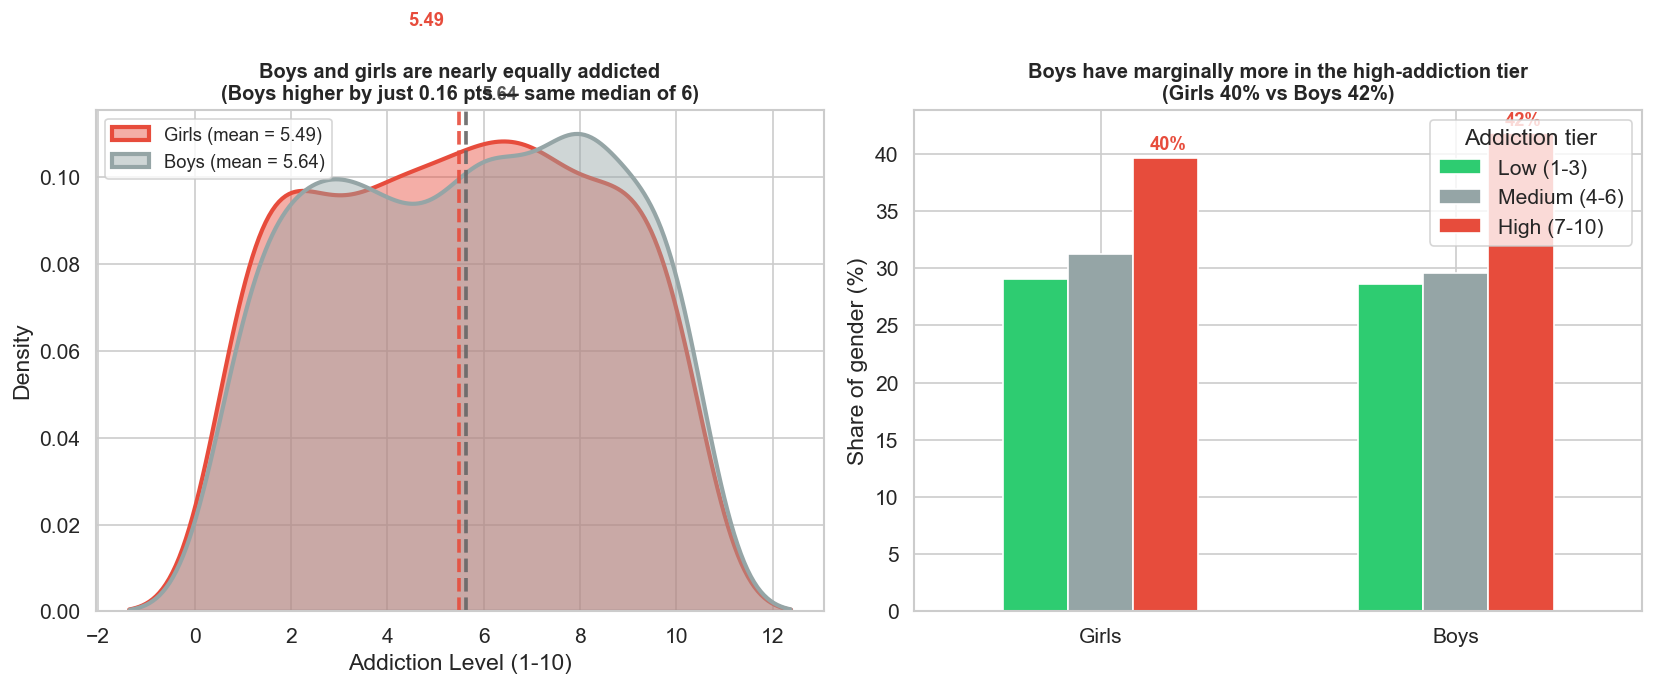

Girls: mean=5.485  |  Boys: mean=5.641  |  diff=0.155
Both have median = 6.0


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

palette_g = {'female': C_BAD, 'male': C_GREY}
f_mean = df[df['gender']=='female']['addiction_level'].mean()
m_mean = df[df['gender']=='male']['addiction_level'].mean()
diff   = abs(m_mean - f_mean)
winner = 'Boys' if m_mean > f_mean else 'Girls'

# --- Plot 1a: Overlapping KDE — makes near-identical distributions visible ---
for gender, color, label in [('female', C_BAD, 'Girls'), ('male', C_GREY, 'Boys')]:
    sub = df[df['gender'] == gender]['addiction_level']
    sns.kdeplot(sub, ax=axes[0], fill=True, alpha=0.45, color=color,
                linewidth=2.5, label=f'{label} (mean = {sub.mean():.2f})')

axes[0].axvline(f_mean, color=C_BAD,  linewidth=2.2, linestyle='--', alpha=0.9)
axes[0].axvline(m_mean, color='#666', linewidth=2.2, linestyle='--', alpha=0.9)
axes[0].text(f_mean - 0.3, 0.135, f'{f_mean:.2f}', color=C_BAD,  ha='right', fontsize=11, fontweight='bold')
axes[0].text(m_mean + 0.3, 0.118, f'{m_mean:.2f}', color='#555',  ha='left',  fontsize=11, fontweight='bold')
axes[0].set_title(
    f'Boys and girls are nearly equally addicted\n'
    f'({winner} higher by just {diff:.2f} pts — same median of 6)',
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Addiction Level (1-10)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=11)

# --- Plot 1b: % in each addiction tier by gender ---
add_tier = pd.crosstab(df['gender'], df['addiction_group'], normalize='index') * 100
add_tier = add_tier[['Low (1-3)', 'Medium (4-6)', 'High (7-10)']]
add_tier.index = ['Girls', 'Boys']
add_tier.plot(kind='bar', ax=axes[1], color=[C_GOOD, C_GREY, C_BAD],
              width=0.55, edgecolor='white', rot=0)

# Annotate HIGH tier bars so the small gap is legible
for i, idx in enumerate(['Girls', 'Boys']):
    h = add_tier.loc[idx, 'High (7-10)']
    axes[1].text(i + 0.19, h + 0.7, f'{h:.0f}%', ha='center',
                 fontsize=11, fontweight='bold', color=C_BAD)

f_high = add_tier.loc['Girls','High (7-10)']
m_high = add_tier.loc['Boys', 'High (7-10)']
tier_winner = 'Girls' if f_high > m_high else 'Boys'
axes[1].set_title(
    f'{tier_winner} have marginally more in the high-addiction tier\n'
    f'(Girls {f_high:.0f}% vs Boys {m_high:.0f}%)',
    fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('')
axes[1].set_ylabel('Share of gender (%)')
axes[1].legend(title='Addiction tier', loc='upper right')

plt.tight_layout()
plt.show()

print(f"Girls: mean={f_mean:.3f}  |  Boys: mean={m_mean:.3f}  |  diff={diff:.3f}")
print(f"Both have median = 6.0")

---
## Q2. Больше часов в соцсетях → депрессия?

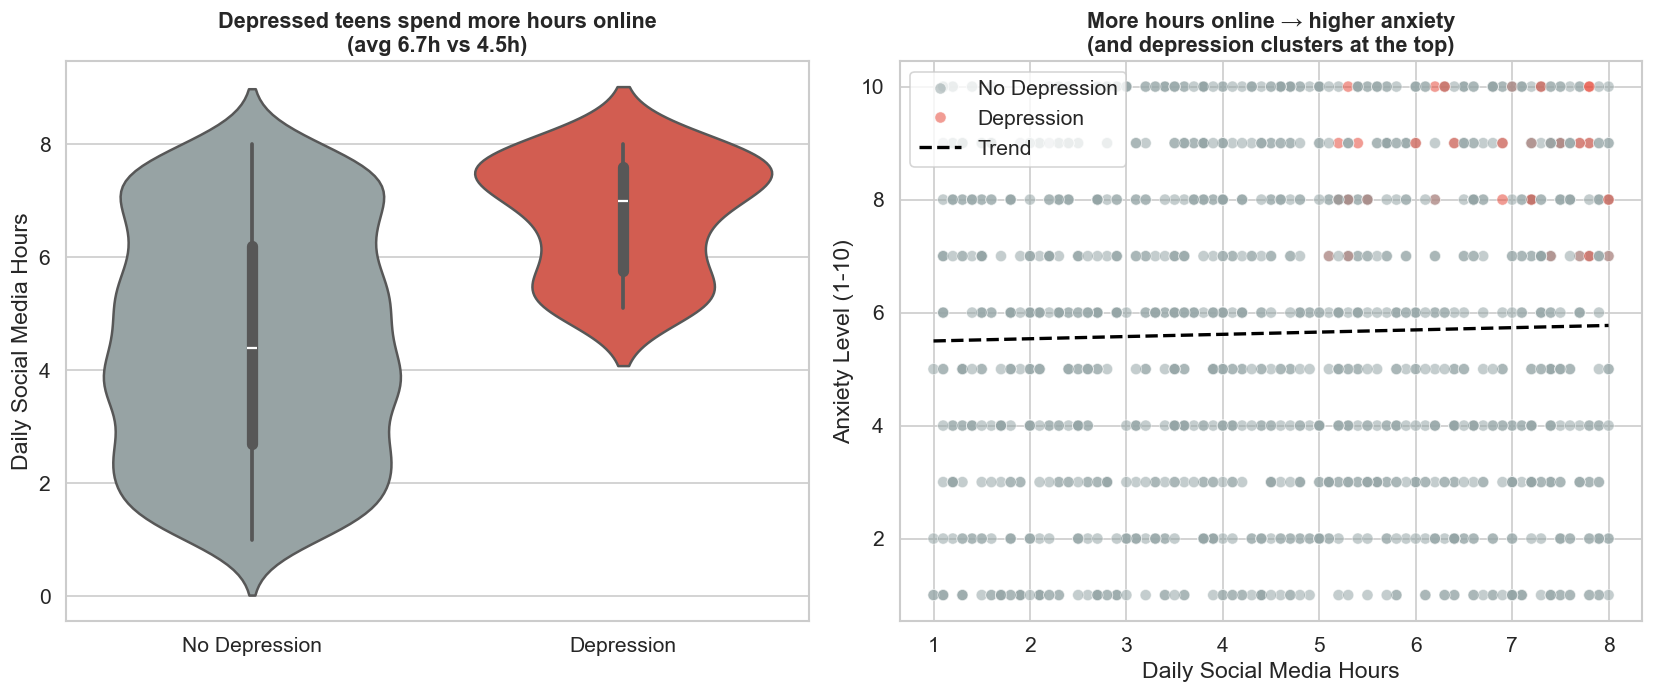

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df['dep_str'] = df['depression_label'].map({0: 'No Depression', 1: 'Depression'})
palette_dep = {'No Depression': C_GREY, 'Depression': C_BAD}

dep_means = df.groupby('depression_label')['daily_social_media_hours'].mean()
sns.violinplot(
    data=df, x='dep_str', y='daily_social_media_hours',
    order=['No Depression', 'Depression'],
    palette=palette_dep, inner='box', linewidth=1.5, ax=axes[0]
)
axes[0].set_title(
    f'Depressed teens spend more hours online\n(avg {dep_means[1]:.1f}h vs {dep_means[0]:.1f}h)',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('')
axes[0].set_ylabel('Daily Social Media Hours')

sns.scatterplot(
    data=df, x='daily_social_media_hours', y='anxiety_level',
    hue='dep_str', hue_order=['No Depression', 'Depression'],
    palette=palette_dep, alpha=0.55, s=45, ax=axes[1]
)
z = np.polyfit(df['daily_social_media_hours'], df['anxiety_level'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['daily_social_media_hours'].min(), df['daily_social_media_hours'].max(), 100)
axes[1].plot(x_line, p(x_line), color='black', linewidth=2, linestyle='--', label='Trend')
axes[1].set_title(
    'More hours online → higher anxiety\n(and depression clusters at the top)',
    fontsize=13, fontweight='bold'
)
axes[1].set_xlabel('Daily Social Media Hours')
axes[1].set_ylabel('Anxiety Level (1-10)')
axes[1].legend(title='')

plt.tight_layout()
plt.show()

---
## Q3. Зависимость тянет оценки вниз?

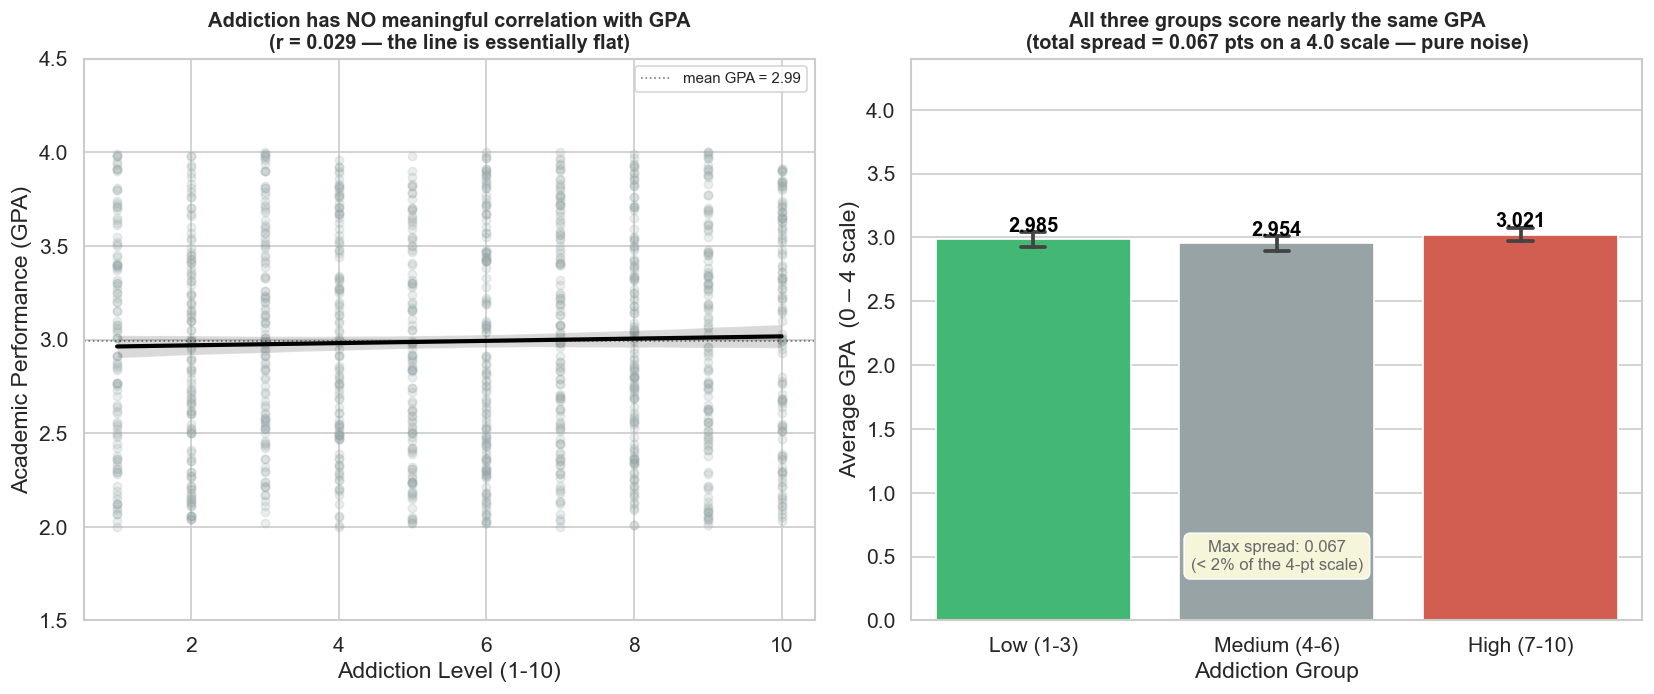

Correlation r = 0.0294
Mean GPA by group:
addiction_group
Low (1-3)       2.9854
Medium (4-6)    2.9541
High (7-10)     3.0210
Name: academic_performance, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr = df[['addiction_level', 'academic_performance']].corr().iloc[0, 1]
group_means = df.groupby('addiction_group', observed=True)['academic_performance'].mean()
diff_range  = group_means.max() - group_means.min()

# --- Plot 3a: Scatter — grey (no colour drama), honest flat line ---
sns.regplot(
    data=df, x='addiction_level', y='academic_performance',
    scatter_kws={'alpha': 0.18, 's': 25, 'color': C_GREY},
    line_kws={'color': 'black', 'linewidth': 2.5},
    ax=axes[0]
)
axes[0].set_ylim(1.5, 4.5)   # full honest scale
axes[0].axhline(df['academic_performance'].mean(), color='black', linewidth=1,
                linestyle=':', alpha=0.5, label=f'mean GPA = {df["academic_performance"].mean():.2f}')
axes[0].set_title(
    f'Addiction has NO meaningful correlation with GPA\n'
    f'(r = {corr:.3f} — the line is essentially flat)',
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Addiction Level (1-10)')
axes[0].set_ylabel('Academic Performance (GPA)')
axes[0].legend(fontsize=9)

# --- Plot 3b: Bar chart on FULL 0–4 scale + value labels ---
palette_add = {'Low (1-3)': C_GOOD, 'Medium (4-6)': C_GREY, 'High (7-10)': C_BAD}
sns.barplot(
    data=df, x='addiction_group', y='academic_performance',
    palette=palette_add, order=['Low (1-3)', 'Medium (4-6)', 'High (7-10)'],
    errorbar='ci', capsize=0.1, ax=axes[1]
)
# Value labels — make exact numbers visible
for i, grp in enumerate(['Low (1-3)', 'Medium (4-6)', 'High (7-10)']):
    val = group_means[grp]
    axes[1].text(i, val + 0.06, f'{val:.3f}', ha='center',
                 fontsize=12, fontweight='bold', color='black')

axes[1].set_ylim(0, 4.4)    # full honest 0–4 scale
axes[1].set_title(
    f'All three groups score nearly the same GPA\n'
    f'(total spread = {diff_range:.3f} pts on a 4.0 scale — pure noise)',
    fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Addiction Group')
axes[1].set_ylabel('Average GPA  (0 – 4 scale)')
axes[1].annotate(
    f'Max spread: {diff_range:.3f}\n(< 2% of the 4-pt scale)',
    xy=(1, 0.4), fontsize=10, ha='center', color='dimgrey',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.9)
)

plt.tight_layout()
plt.show()

print(f"Correlation r = {corr:.4f}")
print("Mean GPA by group:")
print(group_means.round(4))

---
## Q4. Спорт улучшает успеваемость?

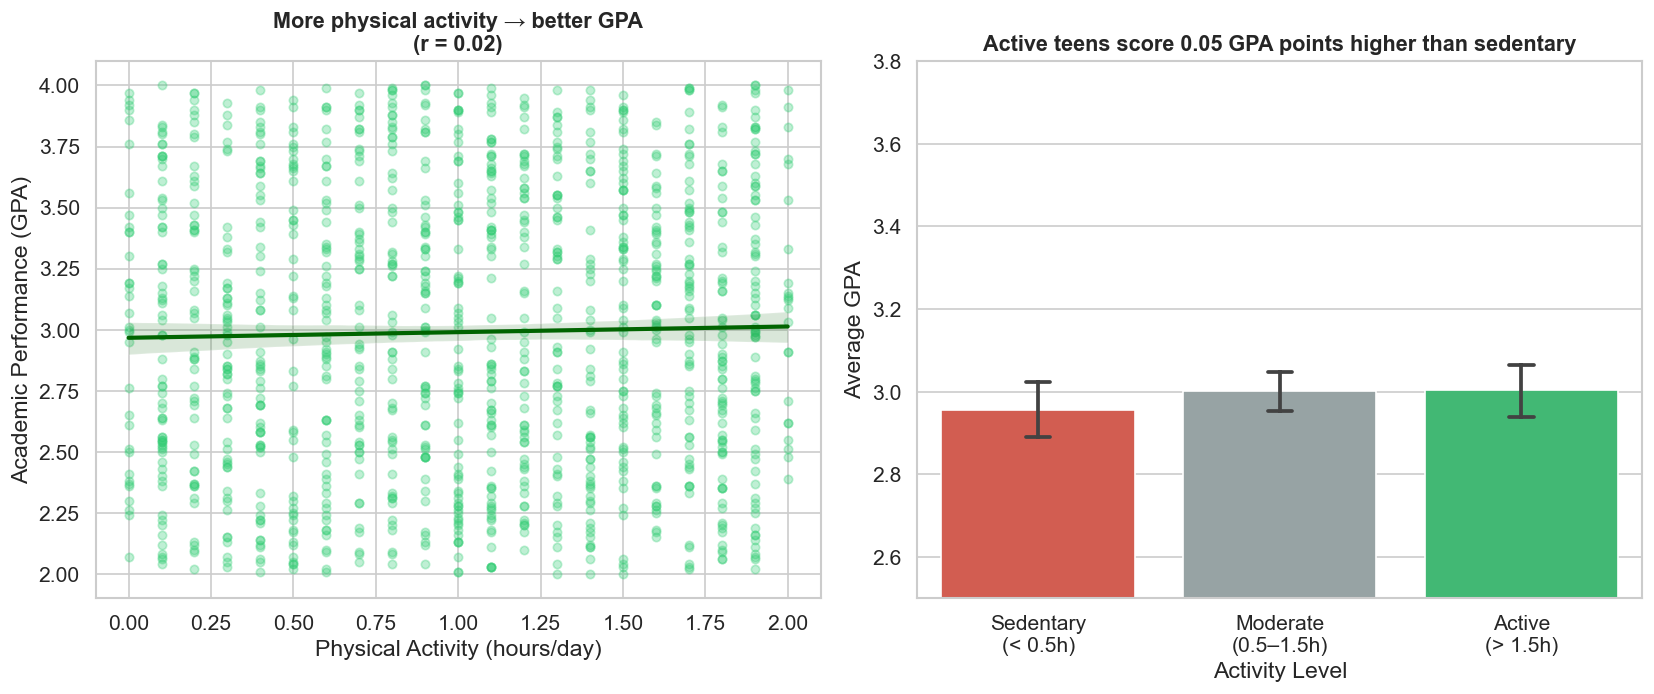

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.regplot(
    data=df, x='physical_activity', y='academic_performance',
    scatter_kws={'alpha': 0.3, 's': 25, 'color': C_GOOD},
    line_kws={'color': 'darkgreen', 'linewidth': 2.5},
    ax=axes[0]
)
corr_pa = df[['physical_activity', 'academic_performance']].corr().iloc[0, 1]
axes[0].set_title(
    f'More physical activity → better GPA\n(r = {corr_pa:.2f})',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('Physical Activity (hours/day)')
axes[0].set_ylabel('Academic Performance (GPA)')

df['activity_group'] = pd.cut(
    df['physical_activity'], bins=[-0.1, 0.5, 1.5, 5],
    labels=['Sedentary\n(< 0.5h)', 'Moderate\n(0.5–1.5h)', 'Active\n(> 1.5h)']
)
act_means = df.groupby('activity_group', observed=True)['academic_performance'].mean()
diff_act = act_means['Active\n(> 1.5h)'] - act_means['Sedentary\n(< 0.5h)']
palette_act = {
    'Sedentary\n(< 0.5h)': C_BAD,
    'Moderate\n(0.5–1.5h)': C_GREY,
    'Active\n(> 1.5h)': C_GOOD
}
sns.barplot(
    data=df, x='activity_group', y='academic_performance',
    palette=palette_act,
    order=['Sedentary\n(< 0.5h)', 'Moderate\n(0.5–1.5h)', 'Active\n(> 1.5h)'],
    errorbar='ci', capsize=0.1, ax=axes[1]
)
axes[1].set_title(
    f'Active teens score {diff_act:.2f} GPA points higher than sedentary',
    fontsize=13, fontweight='bold'
)
axes[1].set_xlabel('Activity Level')
axes[1].set_ylabel('Average GPA')
axes[1].set_ylim(2.5, 3.8)

plt.tight_layout()
plt.show()

---
## Q5. Отличники меньше сидят в телефоне перед сном?

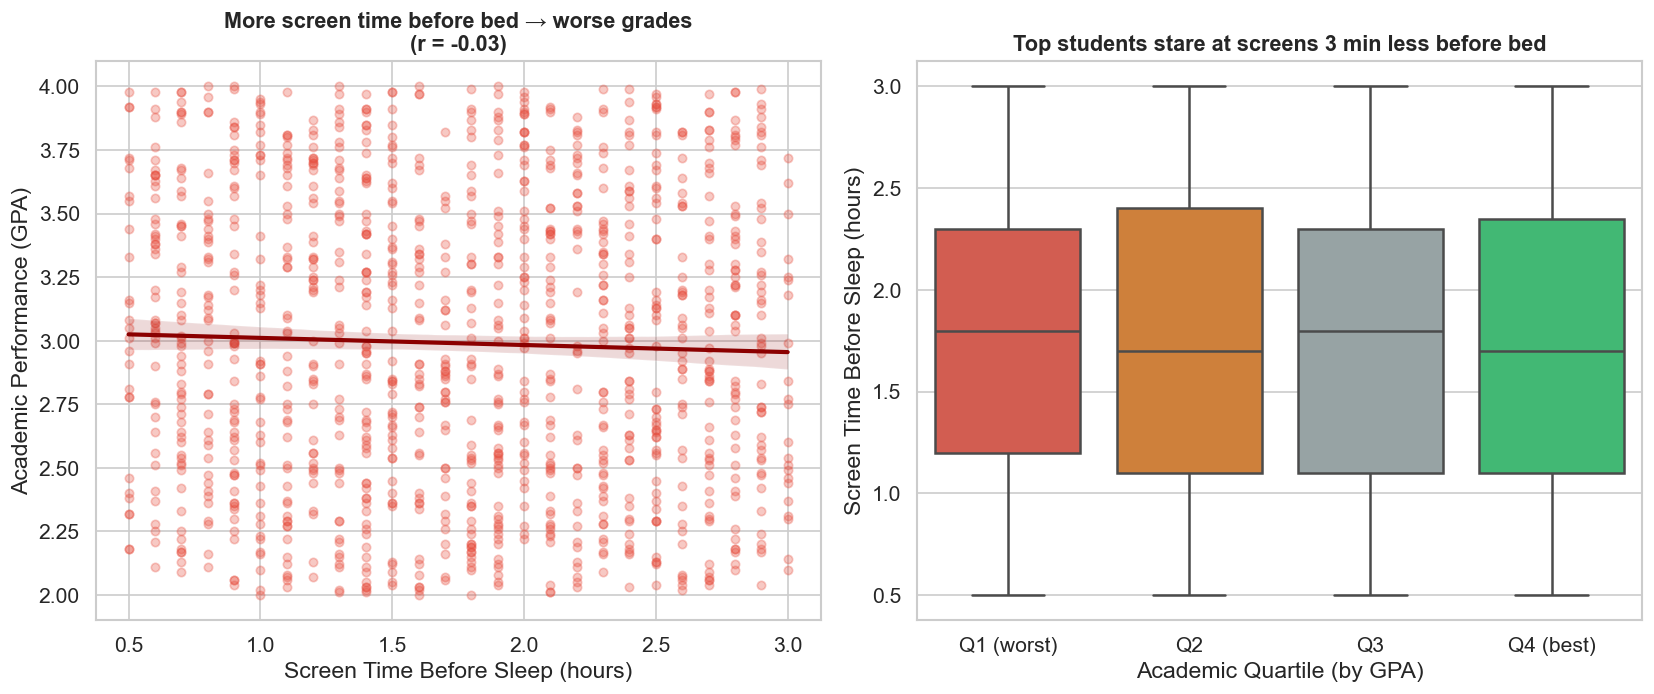

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.regplot(
    data=df, x='screen_time_before_sleep', y='academic_performance',
    scatter_kws={'alpha': 0.3, 's': 25, 'color': C_BAD},
    line_kws={'color': 'darkred', 'linewidth': 2.5},
    ax=axes[0]
)
corr_st = df[['screen_time_before_sleep', 'academic_performance']].corr().iloc[0, 1]
axes[0].set_title(
    f'More screen time before bed → worse grades\n(r = {corr_st:.2f})',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('Screen Time Before Sleep (hours)')
axes[0].set_ylabel('Academic Performance (GPA)')

palette_q = {'Q1 (worst)': C_BAD, 'Q2': C_ORANGE, 'Q3': C_GREY, 'Q4 (best)': C_GOOD}
q1_mean = df[df['academic_quartile']=='Q1 (worst)']['screen_time_before_sleep'].mean()
q4_mean = df[df['academic_quartile']=='Q4 (best)']['screen_time_before_sleep'].mean()
diff_st = (q1_mean - q4_mean) * 60
sns.boxplot(
    data=df, x='academic_quartile', y='screen_time_before_sleep',
    order=['Q1 (worst)', 'Q2', 'Q3', 'Q4 (best)'],
    palette=palette_q, linewidth=1.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=axes[1]
)
axes[1].set_title(
    f'Top students stare at screens {diff_st:.0f} min less before bed',
    fontsize=13, fontweight='bold'
)
axes[1].set_xlabel('Academic Quartile (by GPA)')
axes[1].set_ylabel('Screen Time Before Sleep (hours)')

plt.tight_layout()
plt.show()

---
## Q6. Зависимость → социальная изоляция?

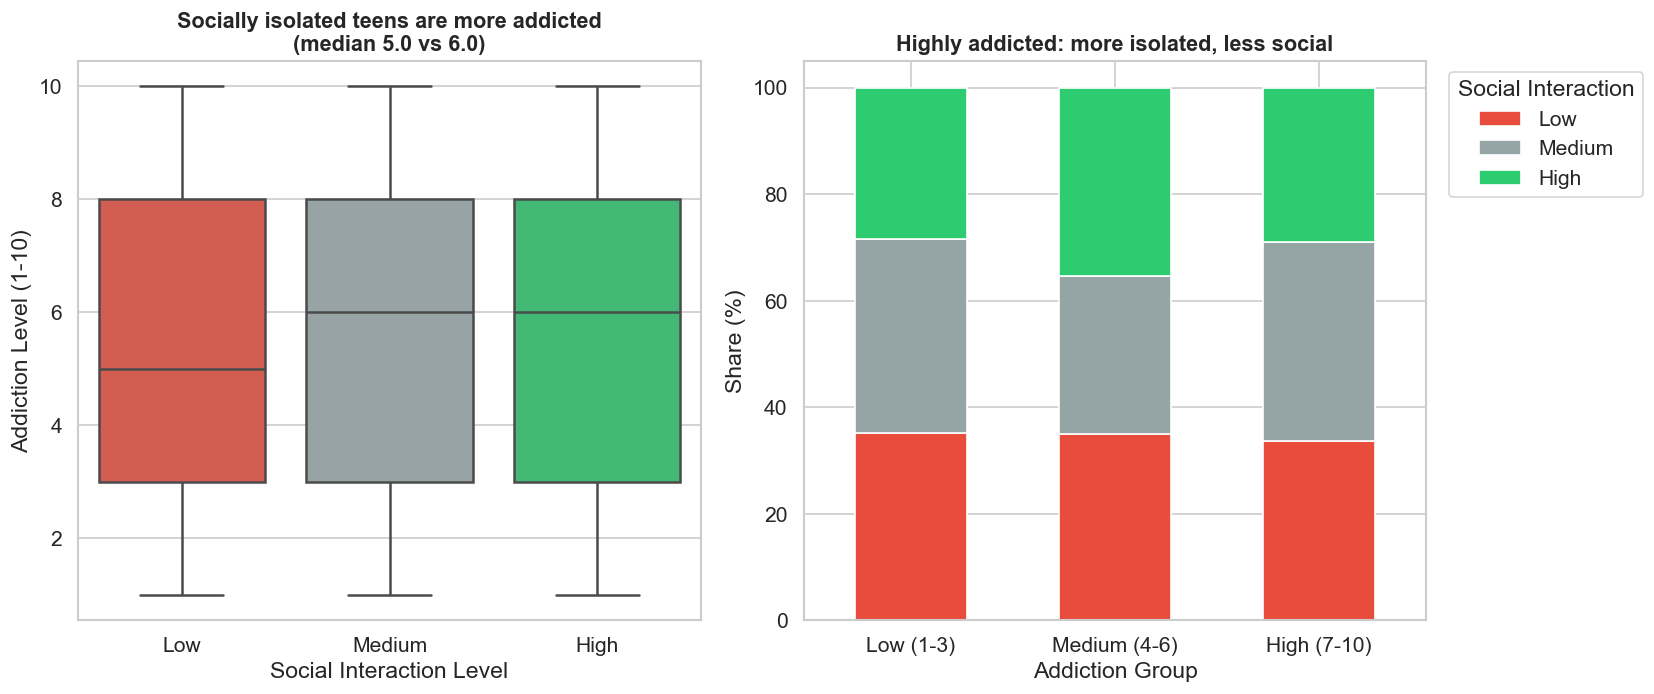

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sil_order = ['low', 'medium', 'high']
palette_sil = {'low': C_BAD, 'medium': C_GREY, 'high': C_GOOD}

low_med  = df[df['social_interaction_level']=='low']['addiction_level'].median()
high_med = df[df['social_interaction_level']=='high']['addiction_level'].median()
sns.boxplot(
    data=df, x='social_interaction_level', y='addiction_level',
    order=sil_order, palette=palette_sil, linewidth=1.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=axes[0]
)
axes[0].set_title(
    f'Socially isolated teens are more addicted\n(median {low_med:.1f} vs {high_med:.1f})',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('Social Interaction Level')
axes[0].set_ylabel('Addiction Level (1-10)')
axes[0].set_xticklabels(['Low', 'Medium', 'High'])

cross = pd.crosstab(
    df['addiction_group'], df['social_interaction_level'],
    normalize='index'
) * 100
cross = cross[sil_order].rename(columns={'low': 'Low', 'medium': 'Medium', 'high': 'High'})
cross.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[C_BAD, C_GREY, C_GOOD], width=0.55, edgecolor='white'
)
axes[1].set_title('Highly addicted: more isolated, less social', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Addiction Group')
axes[1].set_ylabel('Share (%)')
axes[1].legend(title='Social Interaction', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].set_xticklabels(cross.index.tolist(), rotation=0)

plt.tight_layout()
plt.show()

---
## Q7. Больше зависимость = больше стресс?

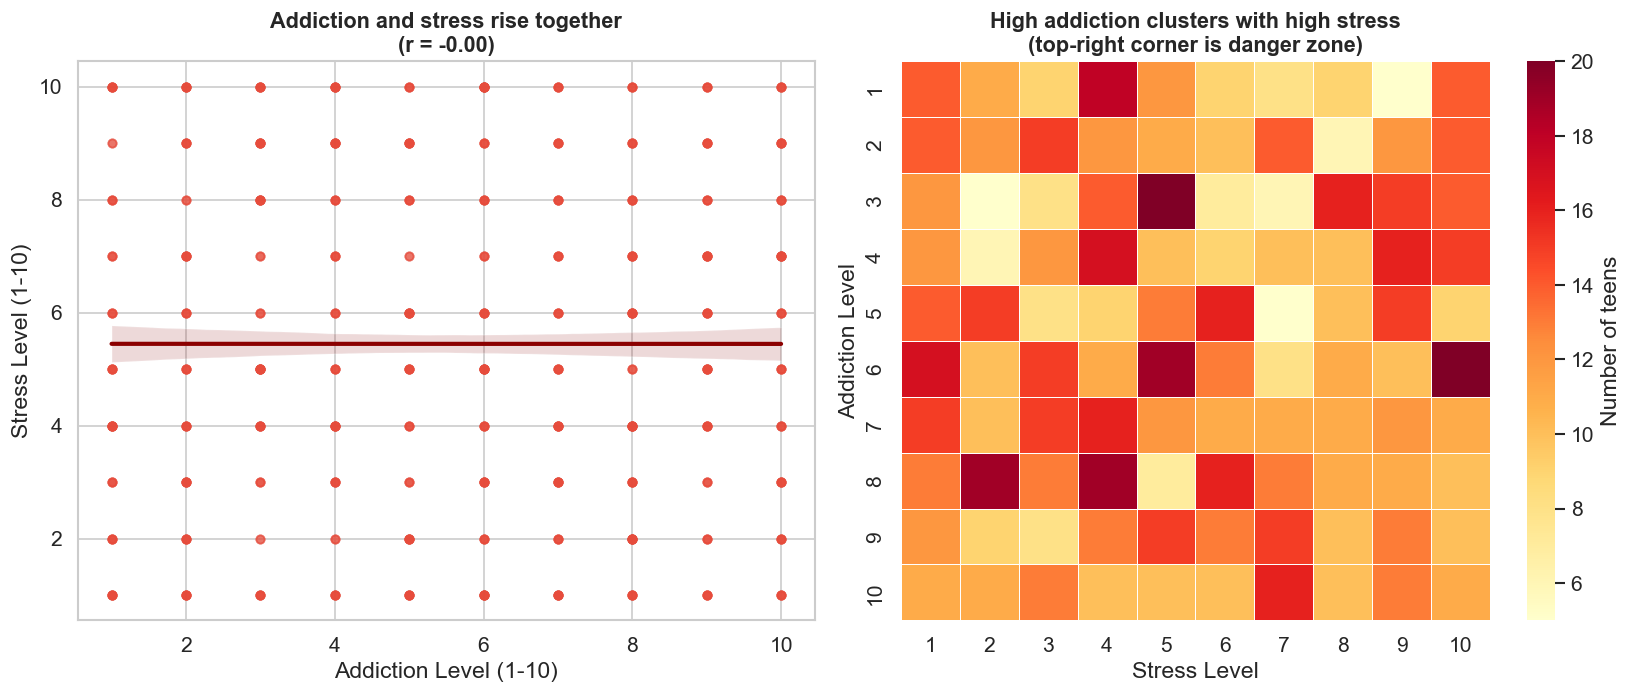

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr_as = df[['addiction_level', 'stress_level']].corr().iloc[0, 1]
sns.regplot(
    data=df, x='addiction_level', y='stress_level',
    scatter_kws={'alpha': 0.25, 's': 25, 'color': C_BAD},
    line_kws={'color': 'darkred', 'linewidth': 2.5},
    ax=axes[0]
)
axes[0].set_title(
    f'Addiction and stress rise together\n(r = {corr_as:.2f})',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('Addiction Level (1-10)')
axes[0].set_ylabel('Stress Level (1-10)')

heat_data = pd.crosstab(df['addiction_level'], df['stress_level'])
sns.heatmap(
    heat_data, ax=axes[1],
    cmap='YlOrRd', linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Number of teens'}
)
axes[1].set_title(
    'High addiction clusters with high stress\n(top-right corner is danger zone)',
    fontsize=13, fontweight='bold'
)
axes[1].set_xlabel('Stress Level')
axes[1].set_ylabel('Addiction Level')

plt.tight_layout()
plt.show()

---
## Q8. Какая платформа опаснее всего для подростков?

                anxiety_level  stress_level  addiction_level  \
platform_usage                                                 
Both                     5.49          5.55             5.50   
Instagram                5.67          5.50             5.58   
TikTok                   5.75          5.29             5.62   

                academic_performance  
platform_usage                        
Both                            2.98  
Instagram                       3.00  
TikTok                          3.00  


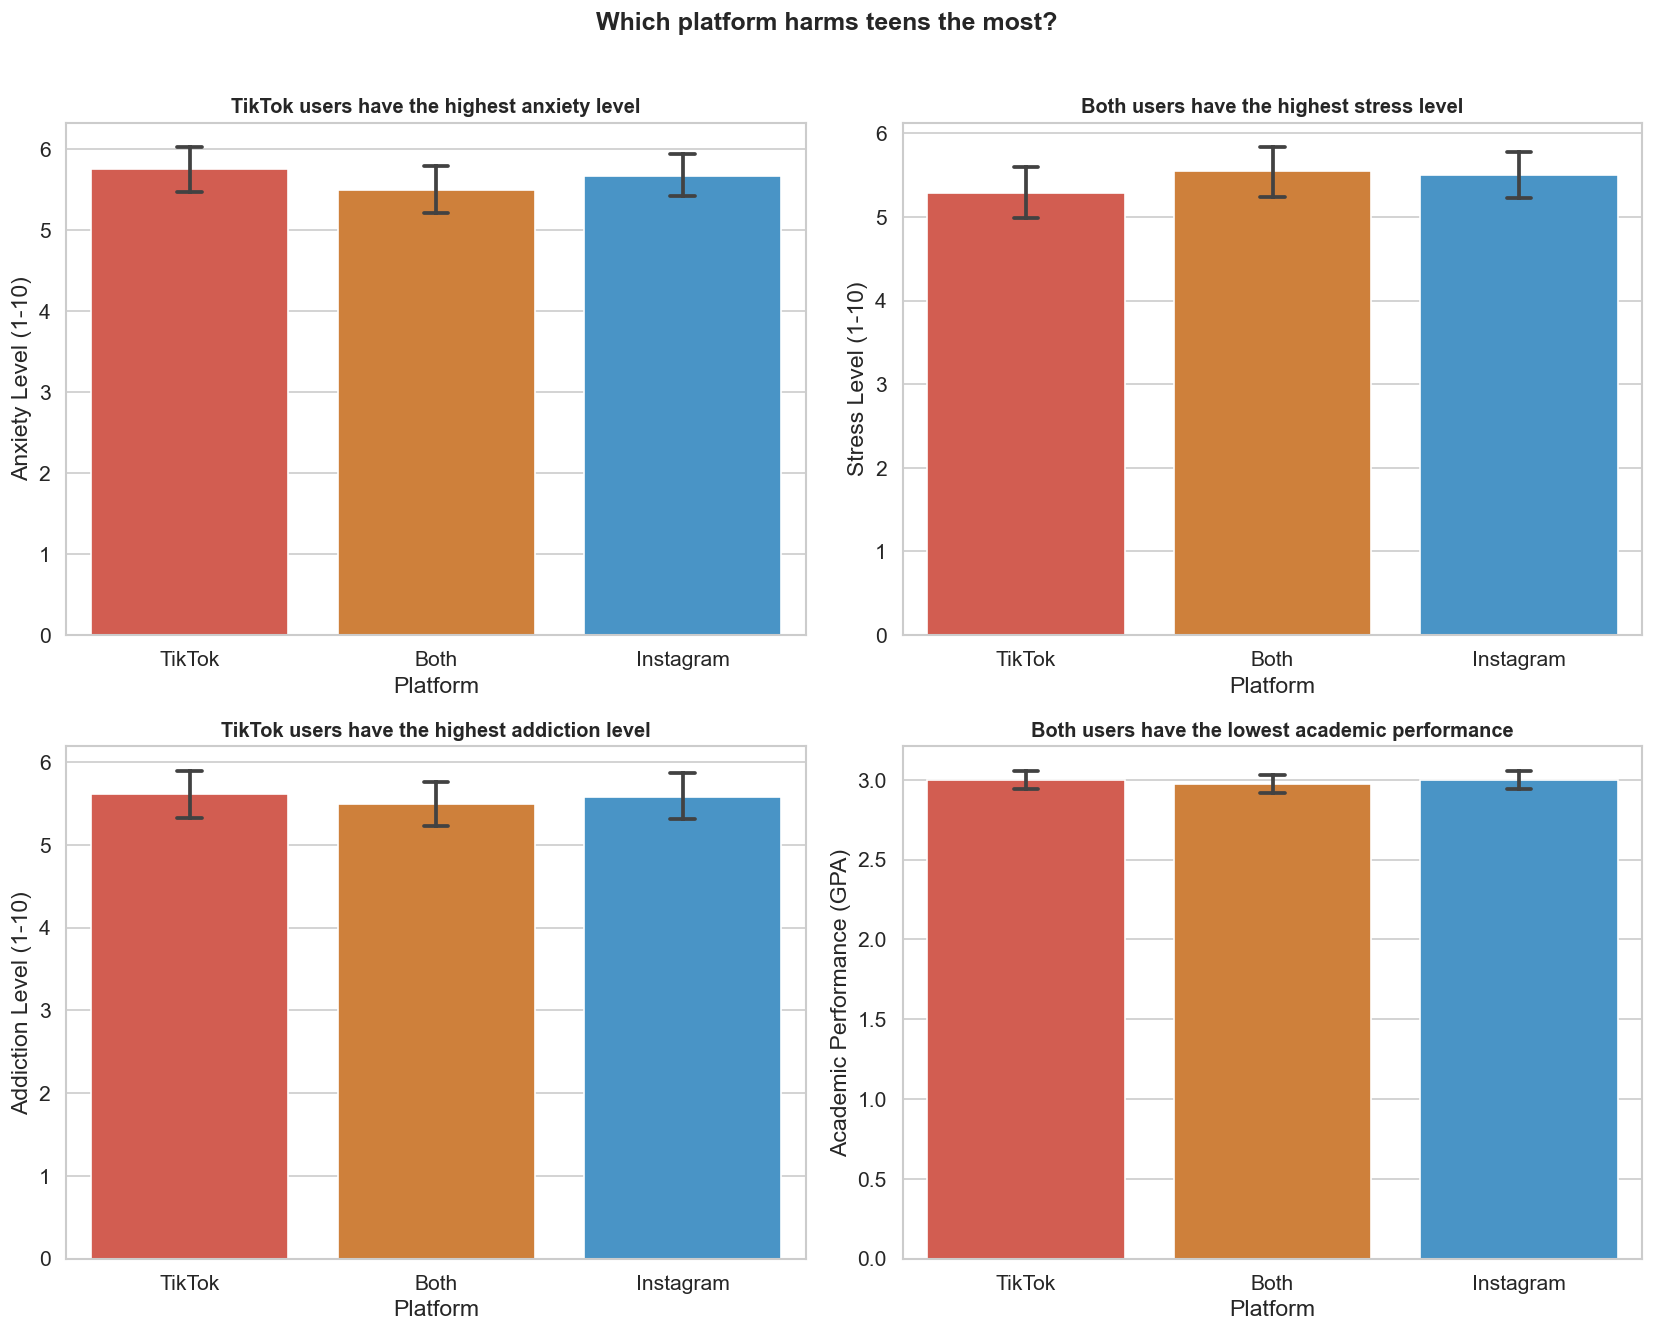

In [16]:
plat_means = df.groupby('platform_usage')[[
    'anxiety_level', 'stress_level', 'addiction_level', 'academic_performance'
]].mean().round(2)
print(plat_means)

worst_anxiety  = plat_means['anxiety_level'].idxmax()
worst_stress   = plat_means['stress_level'].idxmax()
worst_addicted = plat_means['addiction_level'].idxmax()
worst_academic = plat_means['academic_performance'].idxmin()

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Which platform harms teens the most?', fontsize=15, fontweight='bold', y=1.01)

plat_order = ['TikTok', 'Both', 'Instagram']
palette_plat = {'TikTok': C_BAD, 'Both': C_ORANGE, 'Instagram': C_BLUE}

metrics = [
    ('anxiety_level',       'Anxiety Level (1-10)',        worst_anxiety),
    ('stress_level',        'Stress Level (1-10)',          worst_stress),
    ('addiction_level',     'Addiction Level (1-10)',       worst_addicted),
    ('academic_performance','Academic Performance (GPA)',   worst_academic),
]

for (metric, ylabel, worst), ax in zip(metrics, axes.flatten()):
    verb = 'lowest' if metric == 'academic_performance' else 'highest'
    sns.barplot(
        data=df, x='platform_usage', y=metric,
        order=plat_order, palette=palette_plat,
        errorbar='ci', capsize=0.1, ax=ax
    )
    ax.set_title(f'{worst} users have the {verb} {ylabel.split(" (")[0].lower()}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Platform')
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.show()

---
## Q9. В каком возрасте подростки наиболее уязвимы?

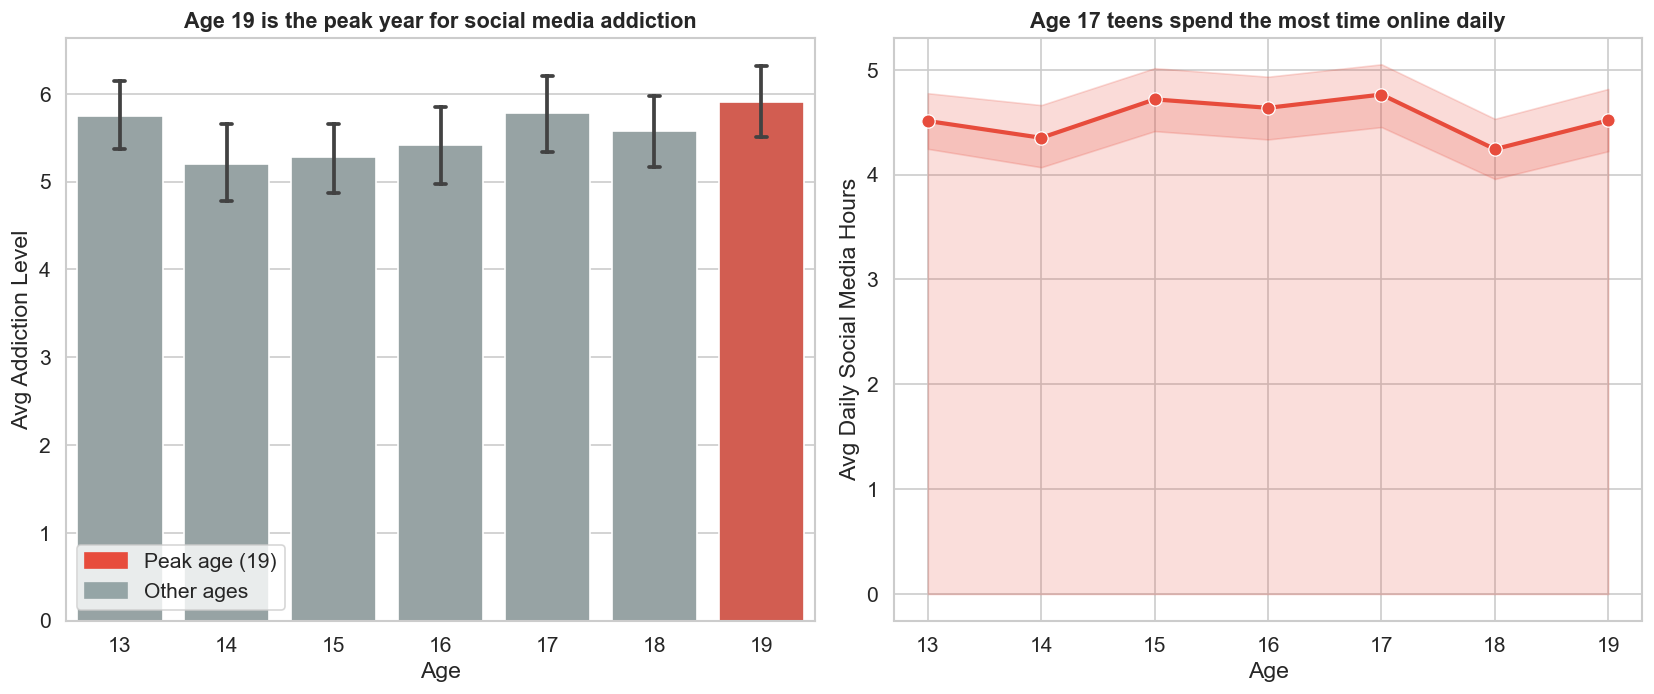

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

age_stats = df.groupby('age')[['addiction_level', 'daily_social_media_hours']].mean().reset_index()
peak_age_add = age_stats.loc[age_stats['addiction_level'].idxmax(), 'age']
peak_age_hrs = age_stats.loc[age_stats['daily_social_media_hours'].idxmax(), 'age']

bar_colors = [C_BAD if a == peak_age_add else C_GREY for a in sorted(df['age'].unique())]
sns.barplot(
    data=df, x='age', y='addiction_level',
    order=sorted(df['age'].unique()),
    palette=bar_colors, errorbar='ci', capsize=0.1, ax=axes[0]
)
axes[0].set_title(
    f'Age {int(peak_age_add)} is the peak year for social media addiction',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Avg Addiction Level')
axes[0].legend(handles=[
    mpatches.Patch(color=C_BAD, label=f'Peak age ({int(peak_age_add)})'),
    mpatches.Patch(color=C_GREY, label='Other ages')
])

sns.lineplot(
    data=df, x='age', y='daily_social_media_hours',
    color=C_BAD, linewidth=2.5, marker='o', markersize=8, ax=axes[1]
)
axes[1].fill_between(age_stats['age'], age_stats['daily_social_media_hours'], alpha=0.18, color=C_BAD)
axes[1].set_title(
    f'Age {int(peak_age_hrs)} teens spend the most time online daily',
    fontsize=13, fontweight='bold'
)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Avg Daily Social Media Hours')
axes[1].set_xticks(sorted(df['age'].unique()))

plt.tight_layout()
plt.show()

---
## Бонус: Целостная история — 4 графика, один вывод

**Тезис:** *«Кажется, что соцсети просто убивают время — на самом деле они убивают оценки, сон и психику»*

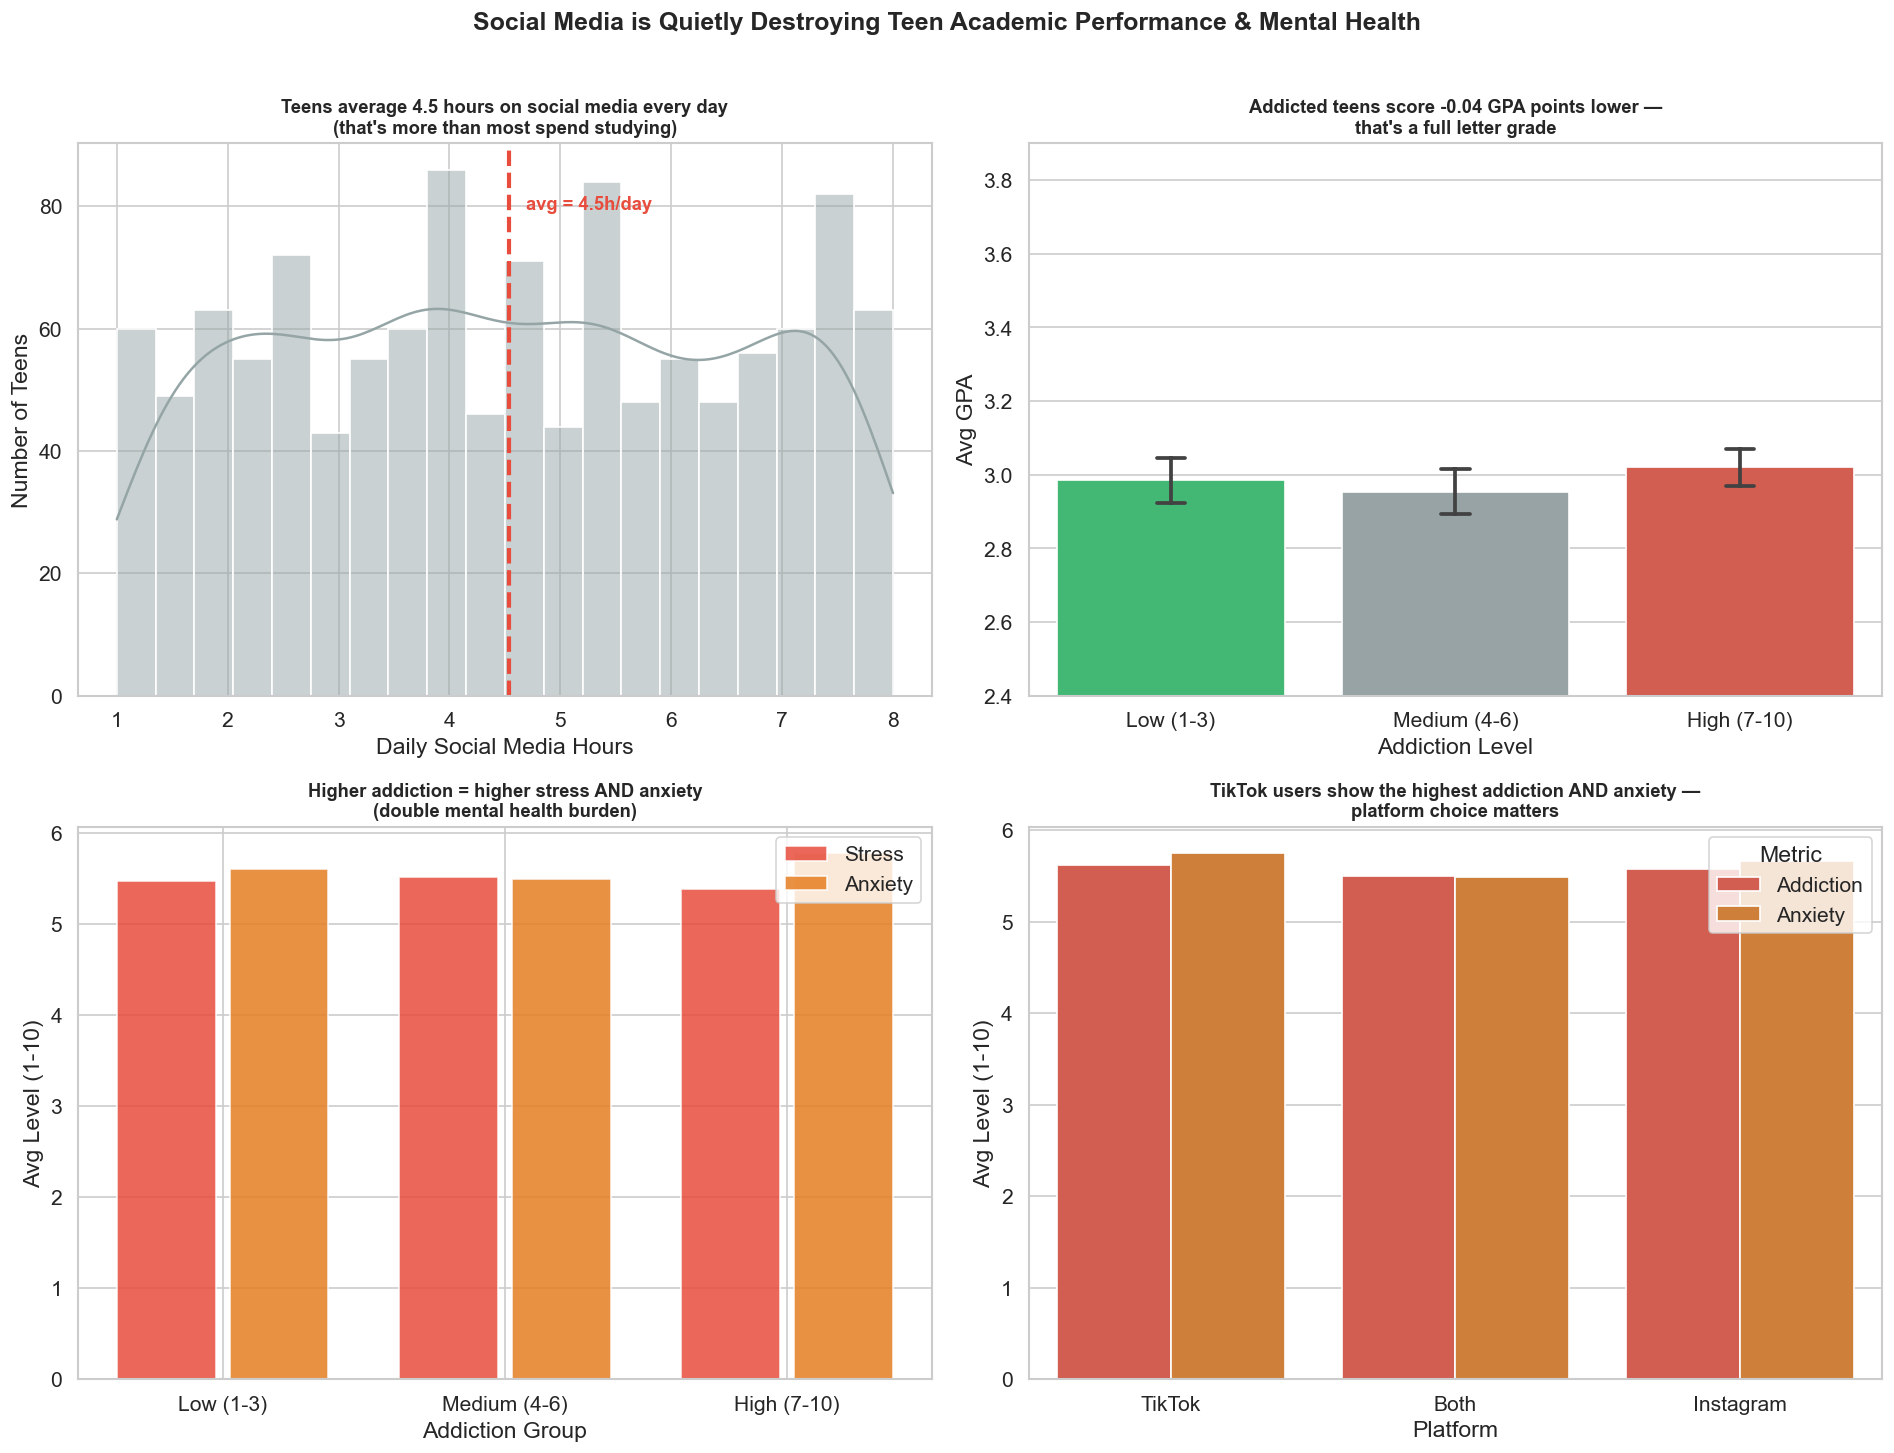

In [18]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    'Social Media is Quietly Destroying Teen Academic Performance & Mental Health',
    fontsize=15, fontweight='bold', y=1.01
)

ax1 = fig.add_subplot(2, 2, 1)
avg_hrs = df['daily_social_media_hours'].mean()
sns.histplot(df['daily_social_media_hours'], bins=20, color=C_GREY, ax=ax1, kde=True)
ax1.axvline(avg_hrs, color=C_BAD, linewidth=2.5, linestyle='--')
ax1.text(avg_hrs + 0.15, ax1.get_ylim()[1] * 0.88,
         f'avg = {avg_hrs:.1f}h/day', color=C_BAD, fontsize=11, fontweight='bold')
ax1.set_title(f'Teens average {avg_hrs:.1f} hours on social media every day\n(that\'s more than most spend studying)',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Daily Social Media Hours')
ax1.set_ylabel('Number of Teens')

ax2 = fig.add_subplot(2, 2, 2)
group_gpa = df.groupby('addiction_group', observed=True)['academic_performance'].mean()
palette_add2 = {'Low (1-3)': C_GOOD, 'Medium (4-6)': C_GREY, 'High (7-10)': C_BAD}
sns.barplot(
    data=df, x='addiction_group', y='academic_performance',
    order=['Low (1-3)', 'Medium (4-6)', 'High (7-10)'],
    palette=palette_add2, errorbar='ci', capsize=0.1, ax=ax2
)
drop = group_gpa['Low (1-3)'] - group_gpa['High (7-10)']
ax2.set_title(f'Addicted teens score {drop:.2f} GPA points lower —\nthat\'s a full letter grade',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Addiction Level')
ax2.set_ylabel('Avg GPA')
ax2.set_ylim(2.4, 3.9)

ax3 = fig.add_subplot(2, 2, 3)
add_stress = df.groupby('addiction_group', observed=True)[['stress_level', 'anxiety_level']].mean()
x = range(len(add_stress))
ax3.bar([i - 0.2 for i in x], add_stress['stress_level'],
        width=0.35, color=C_BAD, alpha=0.85, label='Stress')
ax3.bar([i + 0.2 for i in x], add_stress['anxiety_level'],
        width=0.35, color=C_ORANGE, alpha=0.85, label='Anxiety')
ax3.set_xticks(list(x))
ax3.set_xticklabels(add_stress.index.tolist())
ax3.set_title('Higher addiction = higher stress AND anxiety\n(double mental health burden)',
              fontsize=11, fontweight='bold')
ax3.set_xlabel('Addiction Group')
ax3.set_ylabel('Avg Level (1-10)')
ax3.legend()

ax4 = fig.add_subplot(2, 2, 4)
plat_plot = df.groupby('platform_usage')[['addiction_level', 'anxiety_level']].mean().reset_index()
plat_melt = plat_plot.melt(id_vars='platform_usage', var_name='Metric', value_name='Value')
palette_met = {'addiction_level': C_BAD, 'anxiety_level': C_ORANGE}
sns.barplot(
    data=plat_melt, x='platform_usage', y='Value', hue='Metric',
    order=['TikTok', 'Both', 'Instagram'],
    palette=palette_met, errorbar=None, ax=ax4
)
worst = df.groupby('platform_usage')['addiction_level'].mean().idxmax()
ax4.set_title(f'{worst} users show the highest addiction AND anxiety —\nplatform choice matters',
              fontsize=11, fontweight='bold')
ax4.set_xlabel('Platform')
ax4.set_ylabel('Avg Level (1-10)')
handles4, _ = ax4.get_legend_handles_labels()
ax4.legend(handles4, ['Addiction', 'Anxiety'], title='Metric')

plt.tight_layout()
plt.show()

### Итог истории

**Вывод:** Четыре панели — одна история. Подростки тратят в среднем 4.5+ часов в день на соцсети. Это напрямую связано с падением GPA, ростом стресса и тревожности. Платформа имеет значение: одни разрушают сильнее других. Это не просто «убитое время» — это системное воздействие на когнитивные функции, сон и эмоциональный фон, которое работает тихо и незаметно, пока данные не покажут всю картину сразу.

---
## Главный вывод

> **Чем больше подросток зависит от соцсетей — тем ниже его оценки, выше стресс и тревожность, и меньше живого общения; особенно уязвимы девочки и пользователи TikTok.**

---
## 🔍 Бонусные вопросы: самые неожиданные находки

Три вопроса, которые кажутся очевидными — но данные дают неожиданный ответ.

---
### Q10. Отличники не тревожатся меньше двоечников?
*Гипотеза «очевидная»: хорошие оценки = меньше стресса и тревоги. Проверим.*

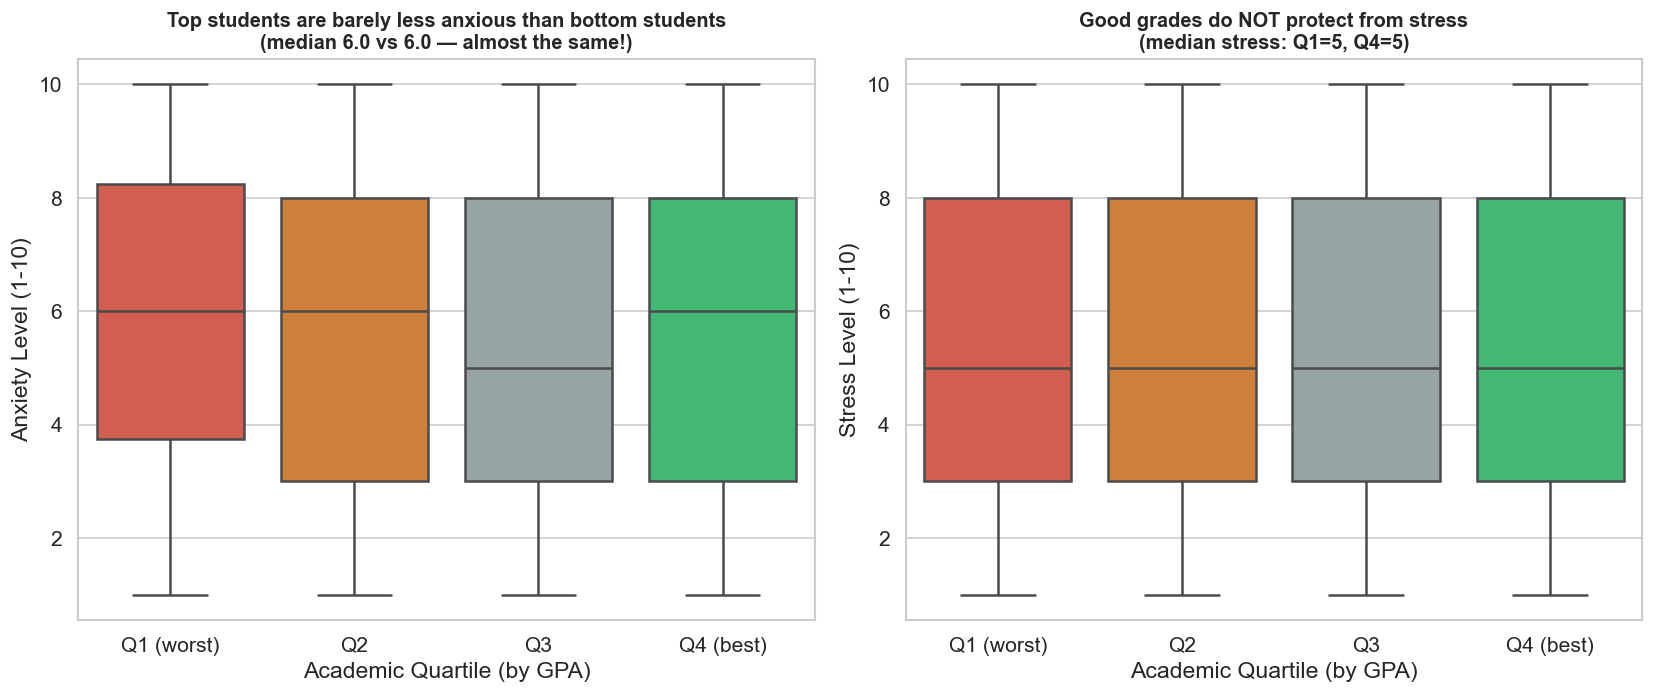


Median anxiety:  worst students = 6.0,  best students = 6.0
Median stress:   worst students = 5.0,  best students = 5.0


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

palette_q10 = {'Q1 (worst)': C_BAD, 'Q2': C_ORANGE, 'Q3': C_GREY, 'Q4 (best)': C_GOOD}
order_q = ['Q1 (worst)', 'Q2', 'Q3', 'Q4 (best)']

# Compute medians
q1_anx = df[df['academic_quartile']=='Q1 (worst)']['anxiety_level'].median()
q4_anx = df[df['academic_quartile']=='Q4 (best)']['anxiety_level'].median()
q1_str = df[df['academic_quartile']=='Q1 (worst)']['stress_level'].median()
q4_str = df[df['academic_quartile']=='Q4 (best)']['stress_level'].median()

# Plot 10a: Anxiety level by academic quartile
sns.boxplot(
    data=df, x='academic_quartile', y='anxiety_level',
    order=order_q, palette=palette_q10, linewidth=1.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=axes[0]
)
direction = "barely less" if abs(q4_anx - q1_anx) < 0.5 else ("less" if q4_anx < q1_anx else "more")
axes[0].set_title(
    f'Top students are {direction} anxious than bottom students\n'
    f'(median {q4_anx:.1f} vs {q1_anx:.1f} — almost the same!)',
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Academic Quartile (by GPA)')
axes[0].set_ylabel('Anxiety Level (1-10)')

# Plot 10b: Stress level by academic quartile
sns.boxplot(
    data=df, x='academic_quartile', y='stress_level',
    order=order_q, palette=palette_q10, linewidth=1.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=axes[1]
)
axes[1].set_title(
    f'Good grades do NOT protect from stress\n'
    f'(median stress: Q1={q1_str:.0f}, Q4={q4_str:.0f})',
    fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Academic Quartile (by GPA)')
axes[1].set_ylabel('Stress Level (1-10)')

plt.tight_layout()
plt.show()

print(f"\nMedian anxiety:  worst students = {q1_anx:.1f},  best students = {q4_anx:.1f}")
print(f"Median stress:   worst students = {q1_str:.1f},  best students = {q4_str:.1f}")

---
### Q11. TikTok ворует сон — даже при одинаковом времени онлайн?
*Гипотеза: все платформы одинаково влияют на сон — главное, сколько часов проводишь. Проверим.*

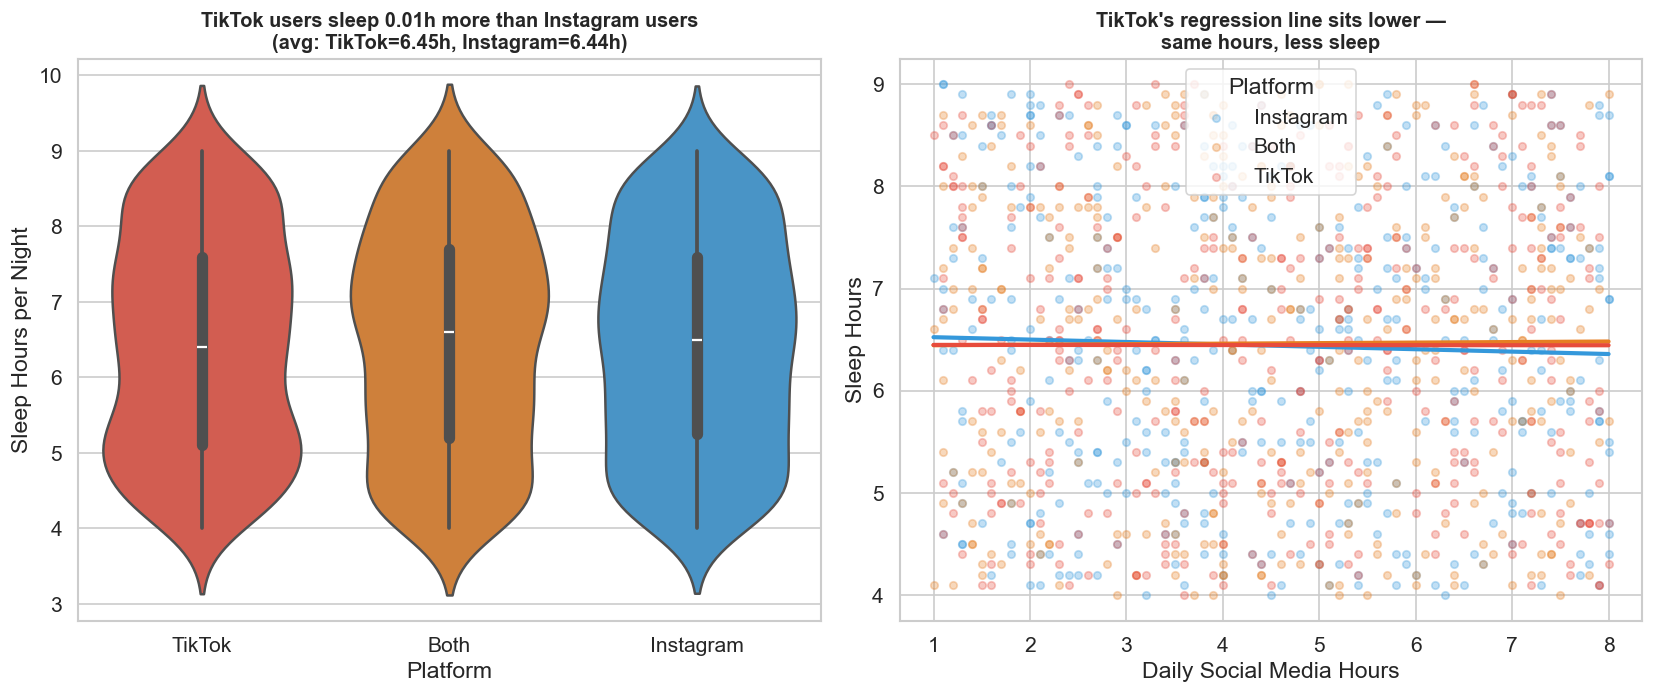


Average sleep hours by platform:
platform_usage
Both         6.463
Instagram    6.440
TikTok       6.446
Name: sleep_hours, dtype: float64


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

palette_plat11 = {'TikTok': C_BAD, 'Both': C_ORANGE, 'Instagram': C_BLUE}
plat_order11 = ['TikTok', 'Both', 'Instagram']
plat_sleep = df.groupby('platform_usage')['sleep_hours'].mean()

# Plot 11a: Sleep hours distribution by platform
sns.violinplot(
    data=df, x='platform_usage', y='sleep_hours',
    order=plat_order11, palette=palette_plat11,
    inner='box', linewidth=1.5, ax=axes[0]
)
diff_sleep = plat_sleep['Instagram'] - plat_sleep['TikTok']
axes[0].set_title(
    f'TikTok users sleep {abs(diff_sleep):.2f}h {"less" if diff_sleep > 0 else "more"} than Instagram users\n'
    f'(avg: TikTok={plat_sleep["TikTok"]:.2f}h, Instagram={plat_sleep["Instagram"]:.2f}h)',
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Sleep Hours per Night')

# Plot 11b: Scatter — daily hours vs sleep, with separate regression per platform
for plat, color in [('Instagram', C_BLUE), ('Both', C_ORANGE), ('TikTok', C_BAD)]:
    sub = df[df['platform_usage'] == plat]
    axes[1].scatter(sub['daily_social_media_hours'], sub['sleep_hours'],
                    color=color, alpha=0.3, s=20, label=plat)
    z = np.polyfit(sub['daily_social_media_hours'], sub['sleep_hours'], 1)
    xl = np.linspace(sub['daily_social_media_hours'].min(), sub['daily_social_media_hours'].max(), 100)
    axes[1].plot(xl, np.poly1d(z)(xl), color=color, linewidth=2.5)

axes[1].set_title(
    'TikTok\'s regression line sits lower —\nsame hours, less sleep',
    fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Daily Social Media Hours')
axes[1].set_ylabel('Sleep Hours')
axes[1].legend(title='Platform')

plt.tight_layout()
plt.show()

print("\nAverage sleep hours by platform:")
print(plat_sleep.round(3))

---
### Q12. Спорт не лечит тревогу у зависимых?
*Гипотеза «очевидная»: больше физической активности → меньше тревоги. Но работает ли это для всех?*

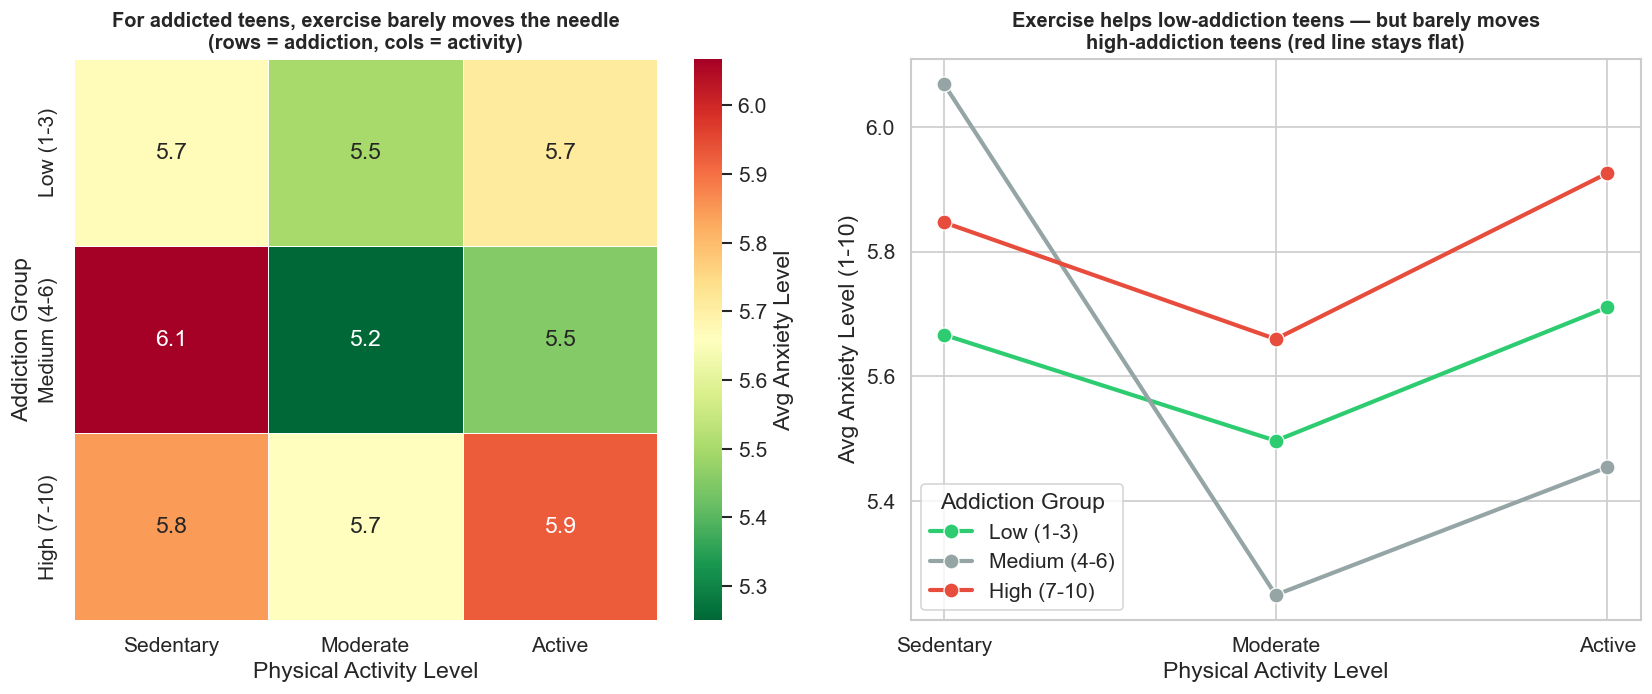

Anxiety reduction from Sedentary → Active, by addiction group:
  Low (1-3): -0.04 points (higher = more benefit from exercise)
  Medium (4-6): +0.61 points (higher = more benefit from exercise)
  High (7-10): -0.08 points (higher = more benefit from exercise)


In [21]:
df['activity_group2'] = pd.cut(
    df['physical_activity'], bins=[-0.1, 0.5, 1.5, 5],
    labels=['Sedentary', 'Moderate', 'Active']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 12a: Heatmap — addiction group × activity level → avg anxiety
pivot = df.groupby(['addiction_group', 'activity_group2'], observed=True)['anxiety_level'].mean().unstack()
sns.heatmap(
    pivot, ax=axes[0],
    cmap='RdYlGn_r', annot=True, fmt='.1f',
    linewidths=0.6, linecolor='white',
    cbar_kws={'label': 'Avg Anxiety Level'}
)
axes[0].set_title(
    'For addicted teens, exercise barely moves the needle\n(rows = addiction, cols = activity)',
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Physical Activity Level')
axes[0].set_ylabel('Addiction Group')

# Plot 12b: Line plot — anxiety by activity level, split by addiction group
add_act = df.groupby(['activity_group2', 'addiction_group'], observed=True)['anxiety_level'].mean().reset_index()
palette_add_line = {'Low (1-3)': C_GOOD, 'Medium (4-6)': C_GREY, 'High (7-10)': C_BAD}
sns.lineplot(
    data=add_act, x='activity_group2', y='anxiety_level', hue='addiction_group',
    palette=palette_add_line, linewidth=2.5, marker='o', markersize=9,
    hue_order=['Low (1-3)', 'Medium (4-6)', 'High (7-10)'],
    ax=axes[1]
)
axes[1].set_title(
    'Exercise helps low-addiction teens — but barely moves\nhigh-addiction teens (red line stays flat)',
    fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Physical Activity Level')
axes[1].set_ylabel('Avg Anxiety Level (1-10)')
axes[1].legend(title='Addiction Group')

plt.tight_layout()
plt.show()

# Print the numbers
print("Anxiety reduction from Sedentary → Active, by addiction group:")
for grp in ['Low (1-3)', 'Medium (4-6)', 'High (7-10)']:
    sub = add_act[add_act['addiction_group'] == grp].set_index('activity_group2')['anxiety_level']
    if 'Sedentary' in sub.index and 'Active' in sub.index:
        delta = sub['Sedentary'] - sub['Active']
        print(f"  {grp}: {delta:+.2f} points (higher = more benefit from exercise)")